# 03 - Released Key

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import pygame

plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/eog-game-touch/eog-game-touch/ABP_20250813_092519.parquet")

## Rutinas

In [78]:
import pandas as pd
from os.path import basename
import pygame

# === Detectar liberaciones ===
df["key_prev"] = df["key"].shift(1)

pressed_times = df[(df["key_prev"] == 0) & (df["key"] > 0)]["timestamp"].reset_index(drop=True)
df_released = df[(df["key_prev"] > 0) & (df["key"] == 0)][["timestamp", "key_prev"]].reset_index(drop=True)

df_released["press_time"] = pressed_times
df_released["duracion_ms"] = df_released["timestamp"] - df_released["press_time"]

df_released["key_prev"] = df_released["key_prev"].astype(int)
df_released["key_name"] = df_released["key_prev"].apply(pygame.key.name)

# === Añadir código participante ===
archivo_actual = "/Users/Ana/eog-game-touch/eog-game-touch/ABP_20250813_092519.parquet"
codigo_participante = basename(archivo_actual).split('_')[0]  # 'ABP'
df_released["Codigo"] = codigo_participante  

# === Merge con CSV de dominancia ===
dominance_df = pd.read_csv(r"C:\Users\Ana\Documents\Ing Salud\TFG\codigo\Resultados_Roberto_Raton.csv")
dominance_df = dominance_df.rename(columns={"Código": "Codigo"})

data_with_dominance = pd.merge(df_released, dominance_df, on="Codigo", how="left")

# Limpieza opcional (solo si esas columnas existen en el CSV)
cols_drop = [c for c in ["Sujeto","Archivo","Equipo","Fecha"] if c in data_with_dominance.columns]
data_with_dominance = data_with_dominance.drop(columns=cols_drop)

print(data_with_dominance.head())


       timestamp  key_prev     press_time  duracion_ms key_name Codigo  \
0  1755069873506        32  1755069873416           90    space    ABP   
1  1755069877542       107  1755069877458           84        k    ABP   
2  1755069880148       108  1755069880062           86        l    ABP   
3  1755069882580       108  1755069882482           98        l    ABP   
4  1755069884573        46  1755069884486           87        .    ABP   

  Mano Dominante       Sexo  Edad  
0        Derecha  Masculino    10  
1        Derecha  Masculino    10  
2        Derecha  Masculino    10  
3        Derecha  Masculino    10  
4        Derecha  Masculino    10  


DF_RELEASED SIN MERGE CON MANO DOMINANTE

df["key_prev"] = df["key"].shift(1)

- Filtramos directamente las filas donde ocurre el release
mask_release = (df["key_prev"] > 0) & (df["key"] == 0)

df_released = df.loc[mask_release, ["timestamp", "key_prev", "stimuli_color"]].reset_index(drop=True)
df_released = df_released.rename(columns={
    "timestamp": "release_ts",
    "key_prev": "key_code",
    "stimuli_color": "color"   # la renombramos aquí para usarla más cómodo
})


- Ahora añadimos los press (0 -> >0) para calcular la duración
mask_press = (df["key_prev"] == 0) & (df["key"] > 0)
pressed_times = df.loc[mask_press, "timestamp"].reset_index(drop=True)

- Alinear longitudes
n = min(len(df_released), len(pressed_times))
df_released = df_released.iloc[:n].copy()
df_released["press_ts"] = pressed_times.iloc[:n].values
df_released["duracion_ms"] = df_released["release_ts"] - df_released["press_ts"]

- Añadimos nombre de tecla
df_released["key_code"] = df_released["key_code"].astype(int)
df_released["key_name"] = df_released["key_code"].apply(pygame.key.name).str.lower()

print(df_released.head())


## Duración pulsación por tecla

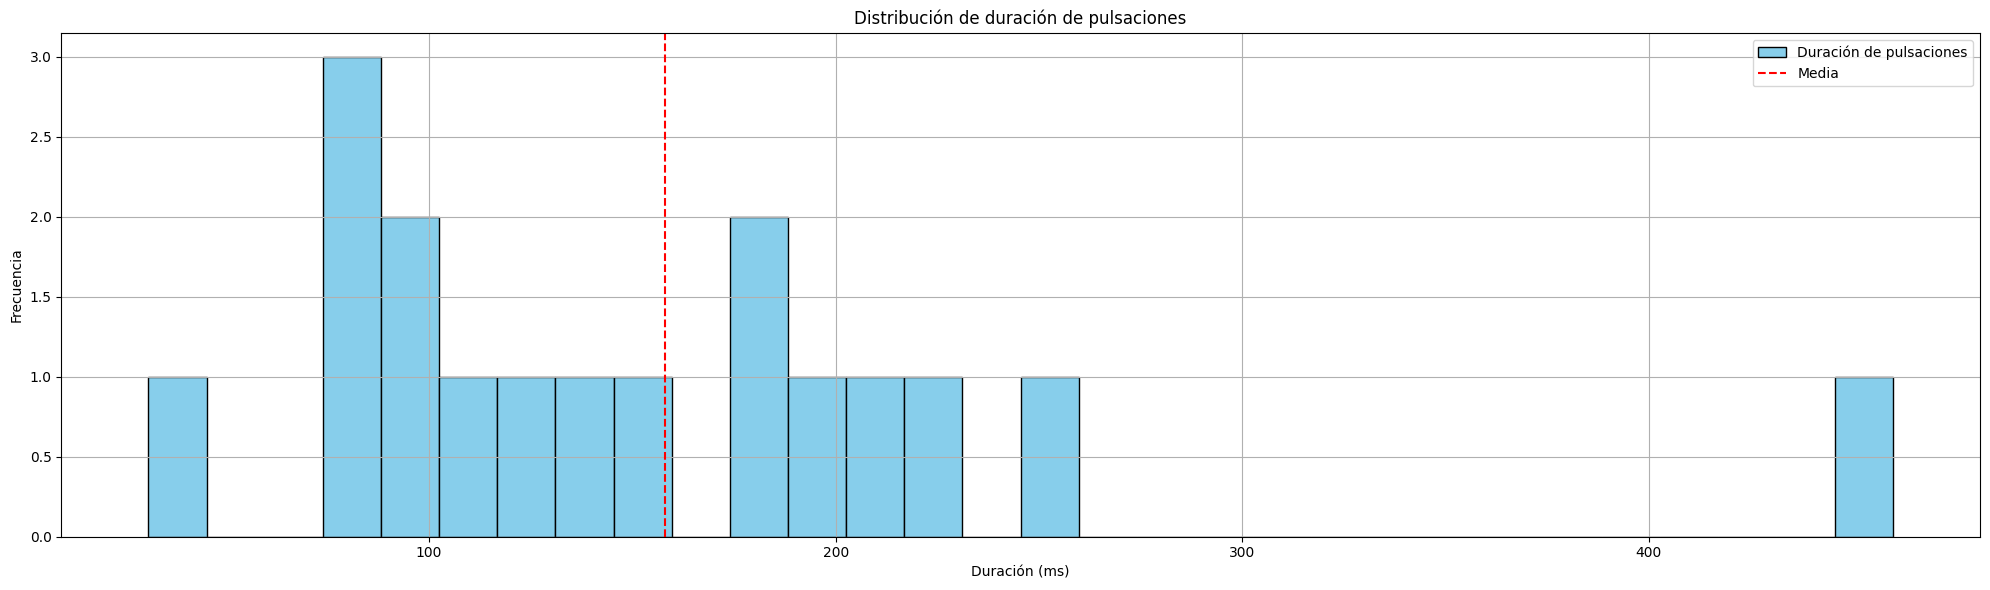

In [79]:
plt.hist(df_released["duracion_ms"], bins=30, color="skyblue", edgecolor="black", label="Duración de pulsaciones")
plt.axvline(df_released["duracion_ms"].mean(), color="r", linestyle="--", label="Media")
plt.xlabel("Duración (ms)")
plt.ylabel("Frecuencia")
plt.title("Distribución de duración de pulsaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Si la mayoría de las pulsaciones duran menos de 200 ms → el usuario teclea rápido.
# Si hay pulsaciones largas o picos raros → puede indicar errores, pausas, o que mantuvo teclas apretadas.

Mismo codigo pero enriquecido con percentiles 

Media: 158.06 ms
Mediana: 136.00 ms
Desviación típica: 98.12 ms


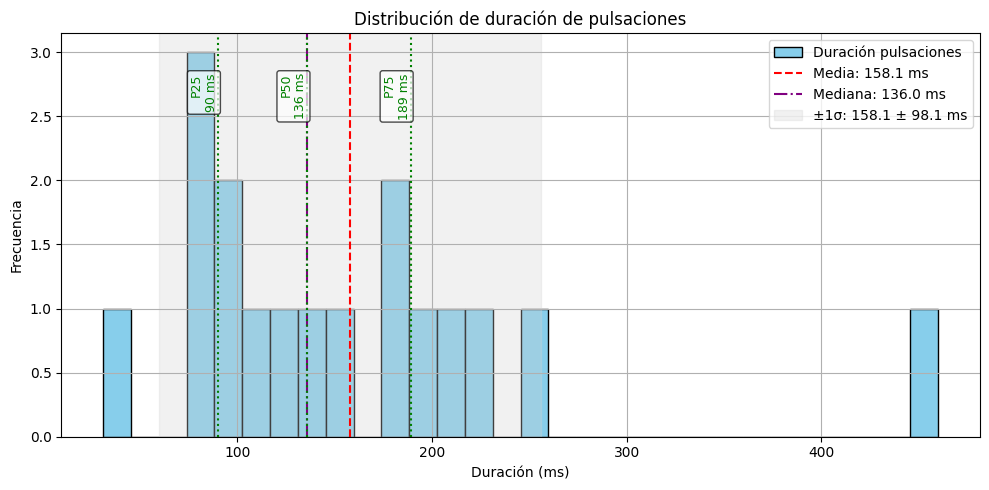

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Serie limpia de duraciones
duraciones = df_released.loc[df_released["duracion_ms"] > 0, "duracion_ms"]

# ===== Estadísticos =====
media = duraciones.mean()
mediana = duraciones.median()
desv = duraciones.std()

print(f"Media: {media:.2f} ms")
print(f"Mediana: {mediana:.2f} ms")
print(f"Desviación típica: {desv:.2f} ms")

# ===== 1) Histograma con media + percentiles =====
plt.figure(figsize=(10,5))
plt.hist(duraciones, bins=30, color="skyblue", edgecolor="black", label="Duración pulsaciones")

# Línea de la media
plt.axvline(media, color="r", linestyle="--", label=f"Media: {media:.1f} ms")

# Línea de la mediana
plt.axvline(mediana, color="purple", linestyle="-.", label=f"Mediana: {mediana:.1f} ms")

# Banda de la desviación típica

plt.axvspan(media - desv, media + desv, color="lightgray", alpha=0.3,
            label=f"±1σ: {media:.1f} ± {desv:.1f} ms")

# Percentiles 25, 50, 75
p25, p50, p75 = np.percentile(duraciones, [25,50,75])
for val, lab in zip([p25,p50,p75], ["P25","P50","P75"]):
    plt.axvline(val, color="g", linestyle=":")
    plt.text(val, plt.ylim()[1]*0.9, f"{lab}\n{val:.0f} ms",
             rotation=90, va="top", ha="right", color="g", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))


plt.xlabel("Duración (ms)")
plt.ylabel("Frecuencia")
plt.title("Distribución de duración de pulsaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Cómo se interpreta:

- Si la mayoría de pulsaciones están <200 ms → el tecleo es rápido y fluido.

- Si hay una cola larga hacia la derecha (>400–500 ms) → indica pulsaciones mantenidas o irregulares (posibles pausas, errores, vacilaciones).

- Si la distribución es muy ancha o multimodal, refleja inconsistencia en el control motor.

Relevancia clínica (SCA2): En sujetos con ataxia se espera:

- Media más alta (tiempos más largos).
- Mayor dispersión (inestabilidad).
- Outliers frecuentes (pulsaciones mantenidas anómalas).

Percentiles: 
- P25 marca el límite inferior de las pulsaciones rápidas.
- P50 (la mediana) es la “pulsación típica”.
- P75 marca el límite superior de las pulsaciones largas.

Detectar dispersión:

La distancia entre P25 y P75 se llama rango intercuartílico (IQR).

- Si el IQR es estrecho → el tecleo es estable.
- Si es ancho → mucha irregularidad (inestabilidad motora en SCA2).

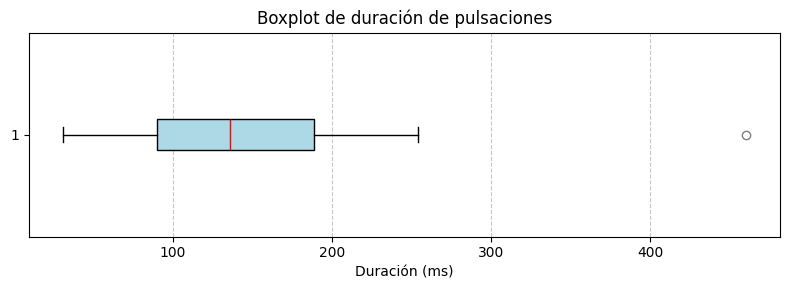

In [81]:

# ===== 2) Boxplot =====
plt.figure(figsize=(8,3))
plt.boxplot(duraciones, vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="black"),
            medianprops=dict(color="red"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color="black", alpha=0.5))
plt.xlabel("Duración (ms)")
plt.title("Boxplot de duración de pulsaciones")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()




BOXPLOT 
Qué es: Una línea horizontal con la mediana (rojo), la caja del rango intercuartílico (P25–P75) y puntos aislados (outliers).

Cómo se interpreta:

- Caja estrecha → tecleo consistente.
- Caja ancha → mucha variabilidad.
- Muchos outliers largos → pulsaciones extremadamente largas (ej. bloqueos motores, dudas).

Relevancia clínica:
En ataxia se espera un boxplot “hinchado” (mayor rango intercuartílico) y con outliers abundantes, porque la persona no mantiene un patrón estable de presión de teclas.

Resumir sin dejarse engañar por outliers:

- La media se distorsiona si hay pulsaciones muy largas.
- La mediana (P50) es más robusta → refleja la pulsación “típica”.

Comparar condiciones o grupos:

Puedes ver si en un grupo clínico (ej. pacientes) los percentiles se desplazan hacia valores más altos (pulsaciones más lentas) o se abren más (más variabilidad).

Visión clínica intuitiva:

En un boxplot, P25–P75 son los bordes de la “caja”. Se interpreta fácilmente: la mayoría de pulsaciones están ahí, y lo que queda fuera son posibles anomalías.

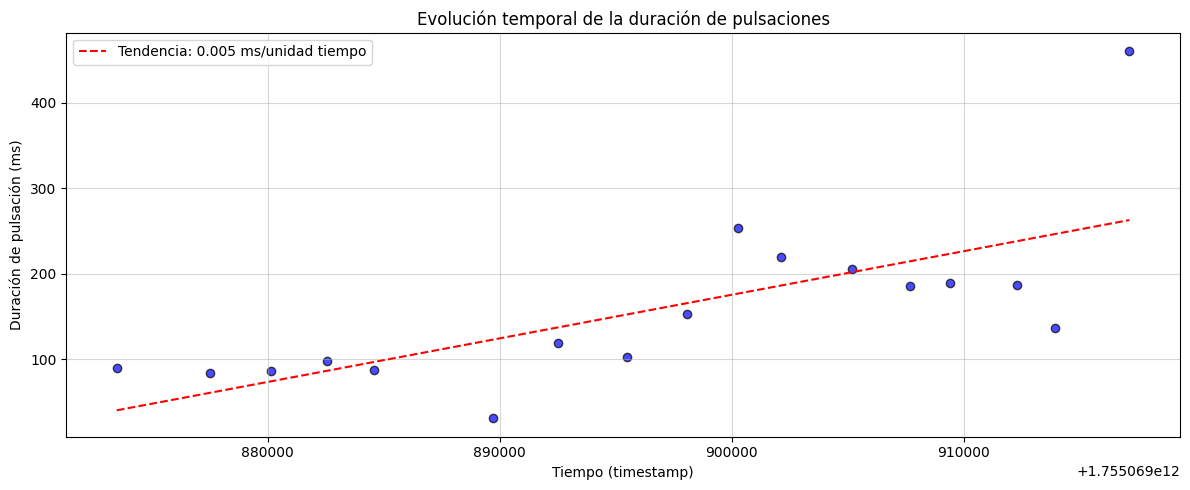

In [82]:
# ===== 3) Timeline (auto-detecta la columna de tiempo) =====
# Busca una columna de tiempo válida en df_released
time_col = next((c for c in ["release_ts", "timestamp", "time", "t"] if c in df_released.columns), None)
if time_col is None:
    raise KeyError("No se encontró columna de tiempo en df_released. Añade 'timestamp' o 'release_ts'.")

# Filtra filas con duración válida y tiempo no nulo
mask = (df_released["duracion_ms"] > 0) & df_released[time_col].notna()
x = df_released.loc[mask, time_col]
y = df_released.loc[mask, "duracion_ms"]

plt.figure(figsize=(12,5))
plt.scatter(x, y, c="blue", alpha=0.7, edgecolors="black")
plt.xlabel(f"Tiempo ({time_col})")
plt.ylabel("Duración de pulsación (ms)")
plt.title("Evolución temporal de la duración de pulsaciones")
plt.grid(True, alpha=0.5)

# Línea de tendencia (solo si hay suficientes puntos)
if len(y) >= 3:
    # Convierte a float por si son timestamps tipo int64
    x_float = x.astype(float)
    coeffs = np.polyfit(x_float, y.astype(float), 1)
    trend = np.polyval(coeffs, x_float)
    plt.plot(x, trend, color="red", linestyle="--",
             label=f"Tendencia: {coeffs[0]:.3f} ms/unidad tiempo")
    plt.legend()

plt.tight_layout()
plt.show()

TEMPORALIDAD
Qué es:
Un gráfico de dispersión de la duración de cada pulsación en función del tiempo. A veces con una línea de tendencia roja.

Cómo se interpreta:

- Si los puntos están estables en el tiempo → el participante mantiene ritmo constante.
- Si la tendencia roja sube → fatigabilidad (cada vez cuesta más, las pulsaciones se alargan).
- Si hay grandes saltos o variabilidad creciente → refleja pérdida de control motor con el paso del tiempo.

Relevancia clínica:
La tendencia creciente es muy típica de patologías progresivas como SCA2: al principio pueden mantener cierta coordinación, pero se deteriora con la repetición.

## Duración pulsaciones según lado del teclado

La idea es observar si hay variabilidad según cada lado del teclado con el objetivo de poder valorar si un hemisferio presenta más afección que otro. Brazo izq controlado por hemisferio derecho, Brazo derecho contorlado por hemisferio izq.

              mean         std  count        cv
lado                                           
Derecha    101.500   45.106224      8  0.444396
Izquierda  223.125  103.999227      8  0.466103
Otro        90.000         NaN      1       NaN


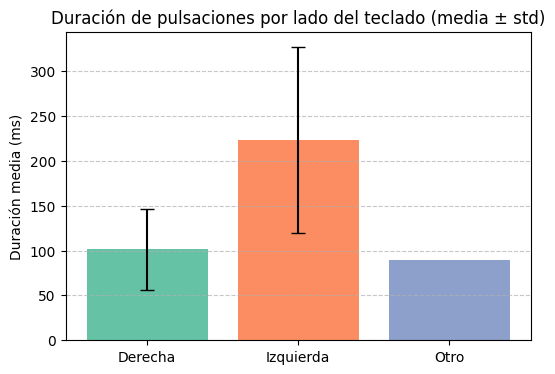

  Mano Dominante       lado     mean         std  count        cv
0        Derecha    Derecha  101.500   45.106224      8  0.444396
1        Derecha  Izquierda  223.125  103.999227      8  0.466103
2        Derecha       Otro   90.000         NaN      1       NaN


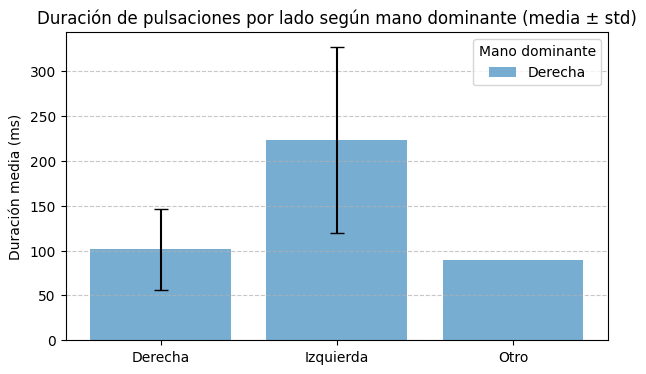

In [83]:
# Definir teclas de cada lado (aprox. teclado QWERTY español)
left_keys  = set("12345qwertasdfgzxcvb")
right_keys = set("67890yuiopñhjklm,.-")

# Clasificar cada tecla
def lado_tecla(tecla):
    if tecla in left_keys: return "Izquierda"
    if tecla in right_keys: return "Derecha"
    return "Otro"

df_released["lado"] = df_released["key_name"].apply(lambda k: lado_tecla(k.lower()))

# Métricas por lado
resumen_lados = df_released.groupby("lado")["duracion_ms"].agg(["mean","std","count"])
resumen_lados["cv"] = resumen_lados["std"] / resumen_lados["mean"]
print(resumen_lados)

import seaborn as sns

resumen = df_released.groupby("lado")["duracion_ms"].agg(["mean","std","count"]).reset_index()

plt.figure(figsize=(6,4))
plt.bar(resumen["lado"], resumen["mean"], yerr=resumen["std"], capsize=5, color=["#66c2a5","#fc8d62","#8da0cb"])
plt.ylabel("Duración media (ms)")
plt.title("Duración de pulsaciones por lado del teclado (media ± std)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

def lado_tecla(tecla):
    if tecla in left_keys: return "Izquierda"
    if tecla in right_keys: return "Derecha"
    return "Otro"

# Asegurarnos de tener la columna 'lado'
data_with_dominance["lado"] = data_with_dominance["key_name"].str.lower().apply(lado_tecla)

# --- Métricas: Mano dominante × lado ---
resumen_lados = (
    data_with_dominance
    .groupby(["Mano Dominante","lado"])["duracion_ms"]
    .agg(["mean","std","count"])
    .reset_index()
)
resumen_lados["cv"] = resumen_lados["std"] / resumen_lados["mean"]
print(resumen_lados)

# --- Gráfico ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
for mano in resumen_lados["Mano Dominante"].unique():
    sub = resumen_lados[resumen_lados["Mano Dominante"] == mano]
    plt.bar(sub["lado"], sub["mean"],
            yerr=sub["std"], capsize=5, alpha=0.6, label=mano)

plt.ylabel("Duración media (ms)")
plt.title("Duración de pulsaciones por lado según mano dominante (media ± std)")
plt.legend(title="Mano dominante")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Cada barra = media de un lado, con una línea de error que marca la variabilidad.
En un barplot con error bars:

- La barra es la media.
- Las líneas que salen arriba y abajo (error bars) indican ±1 std.
- Si son cortas → las pulsaciones son consistentes.
- Si son largas → hay mucha irregularidad.

En ataxias como SCA2 no solo importa que sean más lentos (media mayor), sino que también son menos consistentes (mayor variabilidad). Eso es un biomarcador muy potente: distingue entre alguien que simplemente teclea más despacio (pero regular) y alguien con descoordinación motora (tiempos muy irregulares).

1. ¿Qué significan esas diferencias?

Duración media más baja (101 ms, lado derecho) → las teclas se pulsan más rápido / se sueltan antes.

Duración más alta (223 ms, lado izquierdo) → las teclas se mantienen más tiempo presionadas.

Esto puede reflejar:

Mayor destreza y automatización en el lado dominante (se presiona y se suelta más rápido).

Menor precisión o torpeza en el lado no dominante (se mantiene la tecla más tiempo, quizá para asegurar la pulsación).

2. Posible interpretación clínica

En un sujeto sano, es esperable que el lado dominante sea más rápido y eficiente → por tanto, pulsaciones más cortas.

Si en tus datos apareciera lo contrario (que el lado dominante tarda más en soltar), podría ser un signo de:

Alteración motora fina.

Dificultad en la coordinación ojo-mano.

Algún inicio de disfunción neurológica que afecta a la precisión motora.

3. En tu contexto (ataxia / biomarcadores oculomotores)

Una diferencia muy marcada entre lados podría usarse como un índice de lateralidad funcional.

Si incluso el lado dominante empieza a mostrar duraciones largas (es decir, “lentitud en soltar”), eso podría ser un indicador temprano de deterioro motor fino.

## Duración media de pulsaciones por tecla

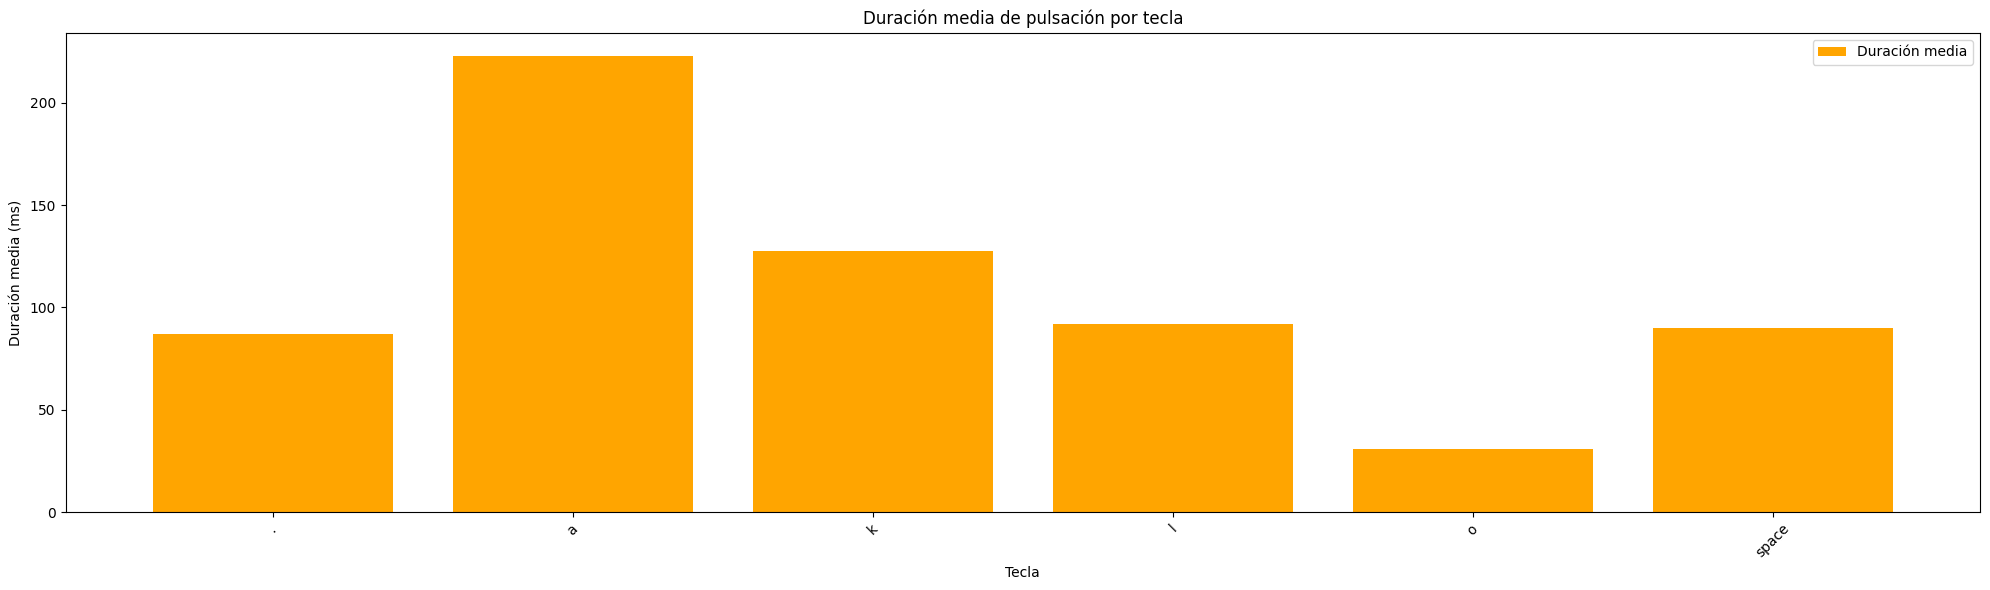

In [84]:
duracion_media = df_released.groupby("key_name")["duracion_ms"].mean()


plt.bar(duracion_media.index, duracion_media.values, color="orange", label="Duración media")
plt.xlabel("Tecla")
plt.ylabel("Duración media (ms)")
plt.title("Duración media de pulsación por tecla")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Frecuencia de teclas presionadas

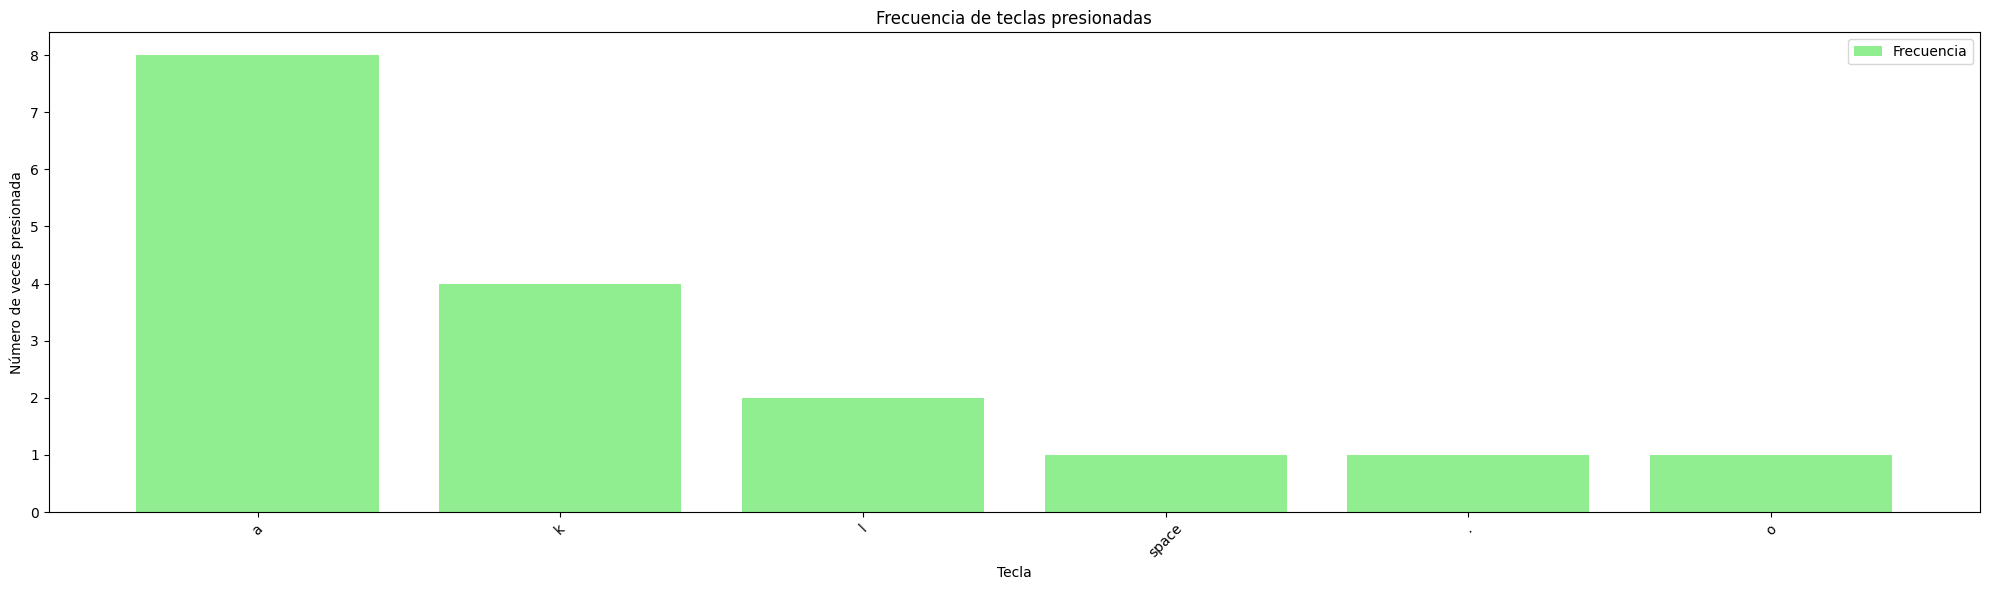

In [85]:
key_counts = df_released["key_name"].value_counts()


plt.bar(key_counts.index, key_counts.values, color="lightgreen", label="Frecuencia")
plt.xlabel("Tecla")
plt.ylabel("Número de veces presionada")
plt.title("Frecuencia de teclas presionadas")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [86]:
# Número de teclas distintas que cada sujeto usa
resumen_participantes = (
    data_with_dominance.groupby(["Codigo","Mano Dominante"])
    .agg(
        total_pulsaciones=("key_name","count"),
        teclas_distintas=("key_name","nunique")
    )
    .reset_index()
)

print("=== Resumen por participante ===")
print(resumen_participantes)


=== Resumen por participante ===
  Codigo Mano Dominante  total_pulsaciones  teclas_distintas
0    ABP        Derecha                 17                 6


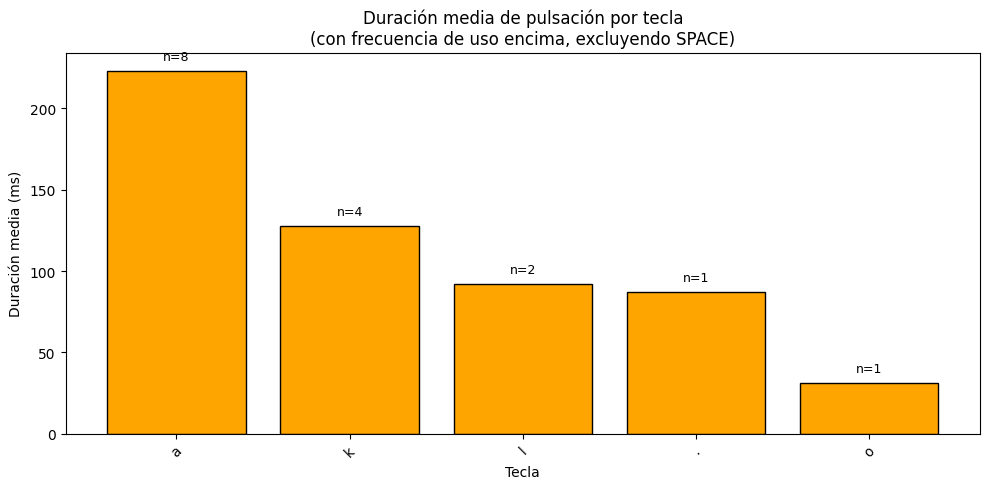

In [87]:
import matplotlib.pyplot as plt

# Filtrar la tecla "space"
df_sin_space = data_with_dominance[data_with_dominance["key_name"] != "space"]

# Calcular duración media y frecuencia por tecla
resumen = (
    df_sin_space.groupby("key_name")["duracion_ms"]
    .agg(["mean","count"])
    .reset_index()
    .sort_values("mean", ascending=False)  # opcional: ordenar por duración
)

# Gráfico combinado
plt.figure(figsize=(10,5))
bars = plt.bar(resumen["key_name"], resumen["mean"], color="orange", edgecolor="black")

# Añadir texto con la frecuencia encima de cada barra
for bar, n in zip(bars, resumen["count"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,    # posición x centrada
        bar.get_height() + 5,              # un poco por encima de la barra
        f"n={n}", ha="center", va="bottom", fontsize=9
    )

plt.xlabel("Tecla")
plt.ylabel("Duración media (ms)")
plt.title("Duración media de pulsación por tecla\n(con frecuencia de uso encima, excluyendo SPACE)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


=== Resumen por participante (incluye totales y distintas por lado) ===
  Codigo Mano Dominante  total_pulsaciones  teclas_distintas  Izquierda  \
0    ABP        Derecha                 16                 5          1   

   Derecha  Otro  
0        4     0  


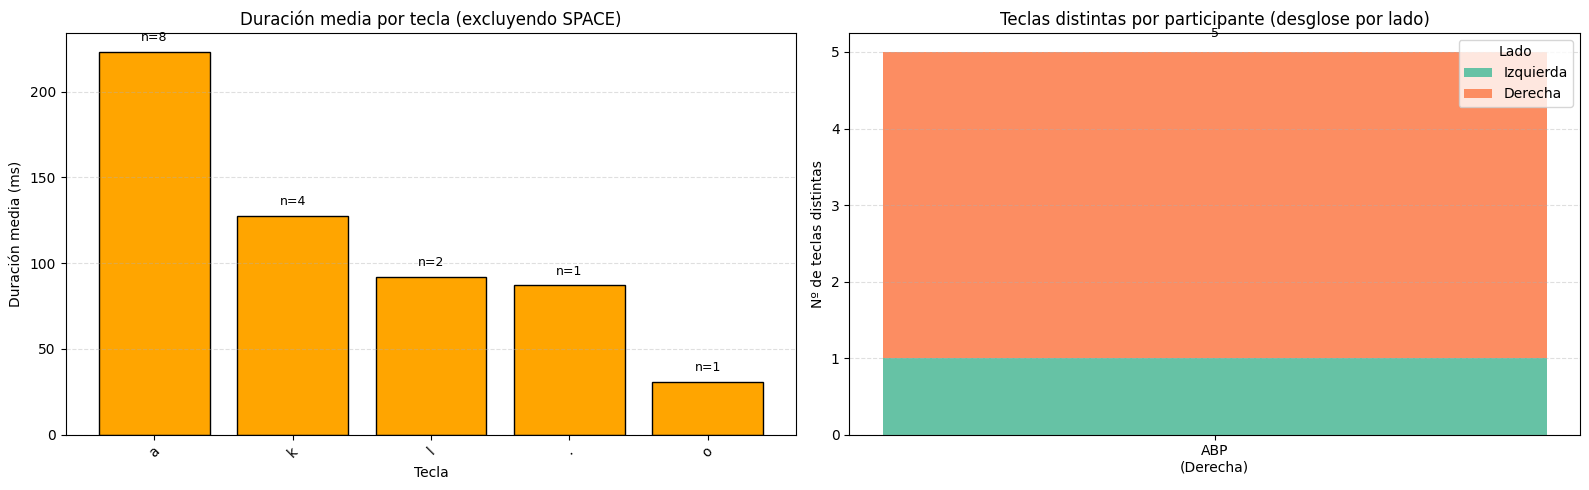

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===== 0) Preparación de datos =====
# Filtrar la tecla "space"
df_sin_space = data_with_dominance[data_with_dominance["key_name"] != "space"].copy()

# Lado por nombre de tecla (QWERTY español aprox.)
left_keys  = set("12345qwertasdfgzxcvb")
right_keys = set("67890yuiopñhjklm,.-")

def lado_tecla(tecla):
    if tecla in left_keys: return "Izquierda"
    if tecla in right_keys: return "Derecha"
    return "Otro"

df_sin_space["lado"] = df_sin_space["key_name"].str.lower().apply(lado_tecla)

# ===== 1) Panel izquierdo: Duración media por tecla + n de veces =====
resumen_teclas = (
    df_sin_space.groupby("key_name")["duracion_ms"]
    .agg(mean="mean", count="count")
    .reset_index()
    .sort_values("mean", ascending=False)  # opcional
)

# ===== 2) Panel derecho: Resumen por participante (teclas distintas por lado) =====
# Distintas por lado
distintas_lado = (
    df_sin_space.groupby(["Codigo","Mano Dominante","lado"])["key_name"]
    .nunique()
    .reset_index(name="teclas_distintas_lado")
)

# Pivot a columnas por lado
distintas_pivot = distintas_lado.pivot(index=["Codigo","Mano Dominante"],
                                       columns="lado",
                                       values="teclas_distintas_lado").fillna(0)

# Asegurar columnas
for c in ["Izquierda","Derecha","Otro"]:
    if c not in distintas_pivot.columns:
        distintas_pivot[c] = 0

distintas_pivot = distintas_pivot.reset_index()

# Totales por participante
totales_part = (
    df_sin_space.groupby(["Codigo","Mano Dominante"])["key_name"]
    .agg(total_pulsaciones="count", teclas_distintas="nunique")
    .reset_index()
)

# Unir totales con el desglose por lado
resumen_participantes = distintas_pivot.merge(totales_part, on=["Codigo","Mano Dominante"], how="left")

print("=== Resumen por participante (incluye totales y distintas por lado) ===")
print(resumen_participantes[["Codigo","Mano Dominante","total_pulsaciones","teclas_distintas","Izquierda","Derecha","Otro"]])

# ===== 3) Figura combinada (2 paneles) =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5))

# --- Panel izquierdo: duración media por tecla + n ---
bars = ax1.bar(resumen_teclas["key_name"], resumen_teclas["mean"],
               color="orange", edgecolor="black", label="Duración media (ms)")
for bar, n in zip(bars, resumen_teclas["count"]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(resumen_teclas["mean"])*0.02,
             f"n={int(n)}", ha="center", va="bottom", fontsize=9)

ax1.set_title("Duración media por tecla (excluyendo SPACE)")
ax1.set_xlabel("Tecla")
ax1.set_ylabel("Duración media (ms)")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# --- Panel derecho: teclas distintas por lado (barras apiladas) ---
# Orden por código para estabilidad
resumen_participantes = resumen_participantes.sort_values(["Codigo","Mano Dominante"])

x = np.arange(len(resumen_participantes))
izq = resumen_participantes["Izquierda"].values
der = resumen_participantes["Derecha"].values
otro = resumen_participantes["Otro"].values  # normalmente será 0 si tu mapa cubre todo

b1 = ax2.bar(x, izq, label="Izquierda", color="#66c2a5")
b2 = ax2.bar(x, der, bottom=izq, label="Derecha", color="#fc8d62")
if (otro > 0).any():
    b3 = ax2.bar(x, otro, bottom=izq+der, label="Otro", color="#8da0cb")

# Anotar TOTAL de teclas distintas encima (izq+der+otro)
tot_distintas = (izq + der + otro).astype(int)
for xi, total in zip(x, tot_distintas):
    ax2.text(xi, total + 0.15, str(total), ha="center", va="bottom", fontsize=9)

# Etiquetas del eje X: codigo (mano)
ax2.set_xticks(x)
ax2.set_xticklabels([f"{c}\n({m})" for c, m in zip(resumen_participantes["Codigo"],
                                                    resumen_participantes["Mano Dominante"])])
ax2.set_ylabel("Nº de teclas distintas")
ax2.set_title("Teclas distintas por participante (desglose por lado)")
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(title="Lado")

plt.tight_layout()
plt.show()


In [89]:
import pandas as pd

# 1) quitar la tecla space (inicio)
df_txt = data_with_dominance[data_with_dominance["key_name"] != "space"].copy()

# 2) lado por tecla (QWERTY español aprox.)
left_keys  = set("12345qwertasdfgzxcvb")
right_keys = set("67890yuiopñhjklm,.-")

def lado_tecla(tecla):
    t = str(tecla).lower()
    if t in left_keys:  return "Izquierda"
    if t in right_keys: return "Derecha"
    return "Otro"

df_txt["lado"] = df_txt["key_name"].apply(lado_tecla)

# 3) resumen por tecla (duración media y frecuencia)
resumen_teclas = (
    df_txt.groupby(["key_name","lado"])["duracion_ms"]
    .agg(mean="mean", count="count")
    .reset_index()
    .sort_values(["count","mean"], ascending=[False, False])
)

# 4) imprimir como texto con color de lado
side_icon = {"Izquierda": "🟩", "Derecha": "🟦", "Otro": "⬜️"}

print("=== Duración media y frecuencia por tecla (excluyendo SPACE) ===")
for _, r in resumen_teclas.iterrows():
    icon = side_icon.get(r["lado"], "⬜️")
    print(f"{icon} {r['key_name']:>3s} → {r['mean']:.1f} ms   (n={int(r['count'])})   [{r['lado']}]")

# 5) resumen por participante: total pulsaciones y teclas distintas (total e Izq/Dcha)
distintas_lado = (
    df_txt.groupby(["Codigo","Mano Dominante","lado"])["key_name"]
    .nunique()
    .reset_index(name="teclas_distintas_lado")
)
pivot_lado = distintas_lado.pivot(index=["Codigo","Mano Dominante"], columns="lado",
                                  values="teclas_distintas_lado").fillna(0).astype(int)
for col in ["Izquierda","Derecha","Otro"]:
    if col not in pivot_lado.columns:
        pivot_lado[col] = 0
pivot_lado = pivot_lado.reset_index()

totales = (
    df_txt.groupby(["Codigo","Mano Dominante"])["key_name"]
    .agg(total_pulsaciones="count", teclas_distintas="nunique")
    .reset_index()
)

resumen_participantes = pivot_lado.merge(totales, on=["Codigo","Mano Dominante"], how="left")

print("\n=== Resumen por participante ===")
for _, r in resumen_participantes.iterrows():
    print(
        f"{r['Codigo']} ({r['Mano Dominante']}): "
        f"total_pulsaciones={int(r['total_pulsaciones'])}, "
        f"teclas_distintas={int(r['teclas_distintas'])} "
        f"[🟩 Izq={int(r['Izquierda'])} | 🟦 Der={int(r['Derecha'])}]"
    )


=== Duración media y frecuencia por tecla (excluyendo SPACE) ===
🟩   a → 223.1 ms   (n=8)   [Izquierda]
🟦   k → 127.5 ms   (n=4)   [Derecha]
🟦   l → 92.0 ms   (n=2)   [Derecha]
🟦   . → 87.0 ms   (n=1)   [Derecha]
🟦   o → 31.0 ms   (n=1)   [Derecha]

=== Resumen por participante ===
ABP (Derecha): total_pulsaciones=16, teclas_distintas=5 [🟩 Izq=1 | 🟦 Der=4]


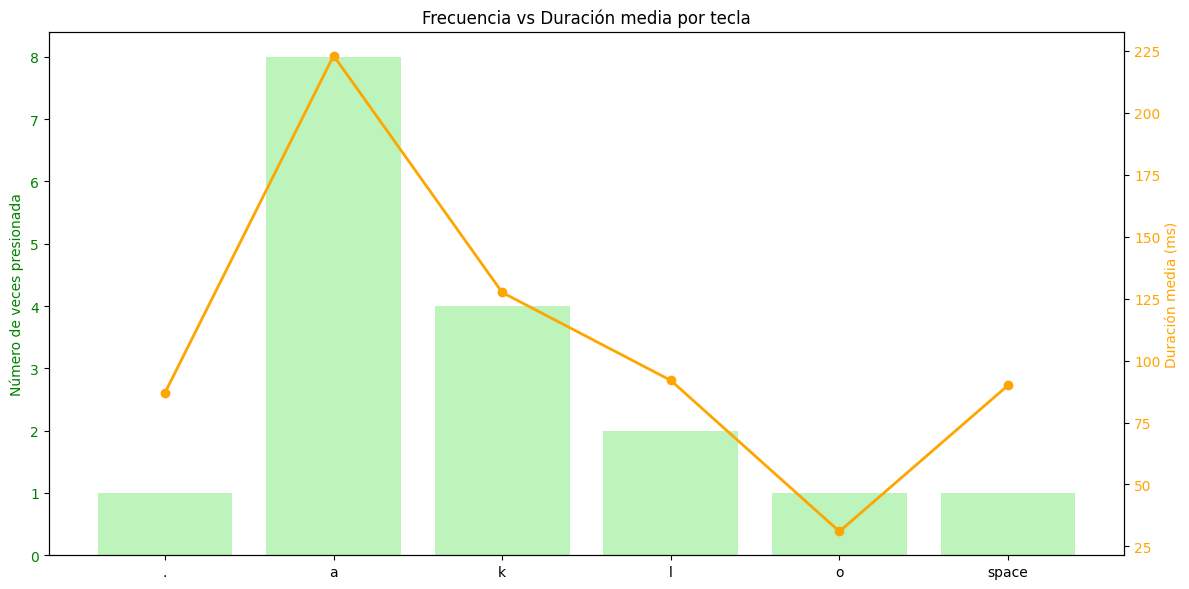

In [90]:
import matplotlib.pyplot as plt

# Frecuencia
key_counts = df_released["key_name"].value_counts()

# Duración media
duracion_media = df_released.groupby("key_name")["duracion_ms"].mean()

# Asegurar que ambas series tienen el mismo orden de teclas
keys = sorted(set(key_counts.index) | set(duracion_media.index))

freq = [key_counts.get(k, 0) for k in keys]
duras = [duracion_media.get(k, 0) for k in keys]

fig, ax1 = plt.subplots(figsize=(12,6))

# Eje izquierdo → frecuencia
ax1.bar(keys, freq, color="lightgreen", alpha=0.6, label="Frecuencia")
ax1.set_ylabel("Número de veces presionada", color="green")
ax1.tick_params(axis="y", labelcolor="green")

# Eje derecho → duración
ax2 = ax1.twinx()
ax2.plot(keys, duras, color="orange", marker="o", linewidth=2, label="Duración media")
ax2.set_ylabel("Duración media (ms)", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Frecuencia vs Duración media por tecla")
fig.tight_layout()
plt.show()
